In [1]:
%pip install pandas matplotlib numpy seaborn scikit-learn flask joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
#Loading the data set
df = pd.read_csv('C:/Users/KIIT/Desktop/MLOPs/electricitybills/dataset/electricity_bill_dataset.csv')
df.head()

,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [4]:
df.columns

Index(['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Month', 'City',
       'Company', 'MonthlyHours', 'TariffRate', 'ElectricityBill', 'season',
       'TotalApplianceHours', 'UsageCategory', 'MonthlyCostPerHour',
       'TariffEfficiency', 'Fan_Contribution', 'Refrigerator_Contribution',
       'AirConditioner_Contribution', 'Television_Contribution'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29619 entries, 0 to 29618
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Fan                          29619 non-null  int64  
 1   Refrigerator                 29619 non-null  float64
 2   AirConditioner               29619 non-null  float64
 3   Television                   29619 non-null  float64
 4   Month                        29619 non-null  int64  
 5   City                         29619 non-null  object 
 6   Company                      29619 non-null  object 
 7   MonthlyHours                 29619 non-null  int64  
 8   TariffRate                   29619 non-null  float64
 9   ElectricityBill              29619 non-null  float64
 10  season                       29619 non-null  object 
 11  TotalApplianceHours          29619 non-null  float64
 12  UsageCategory                29619 non-null  object 
 13  MonthlyCostPerHo

In [6]:
# Data preparation
## Data Cleaning
# Checking missing values
df.isna().sum()

Fan                            0
Refrigerator                   0
AirConditioner                 0
Television                     0
Month                          0
City                           0
Company                        0
MonthlyHours                   0
TariffRate                     0
ElectricityBill                0
season                         0
TotalApplianceHours            0
UsageCategory                  0
MonthlyCostPerHour             0
TariffEfficiency               0
Fan_Contribution               0
Refrigerator_Contribution      0
AirConditioner_Contribution    0
Television_Contribution        0
dtype: int64

In [7]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# Converting electricitybill data type to float for uniformity
df['ElectricityBill'] = df['ElectricityBill'].astype(float)
df['ElectricityBill']

0        3225.6
1        3806.4
2        4370.0
3        4204.4
4        3485.4
          ...  
29614    2861.8
29615    4905.9
29616    2401.2
29617    6035.6
29618    5176.5
Name: ElectricityBill, Length: 29619, dtype: float64

In [9]:
# Feature Engineering
# Method to categorize seasons
def categorize_seasons(Month):
    if Month in [3, 4, 5]:
        return "Summer"
    elif Month in [6, 7, 8, 9]:
        return  "Monsoon"
    else:
        return  "Winter"

    
df['season'] = df['Month'].apply(categorize_seasons)

df.head()


,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [10]:
# MonthlyCostPerHour
df['MonthlyCostPerHour'] = df['ElectricityBill'] / df['MonthlyHours']
df.head()

,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [11]:
df.describe()

,Fan,Refrigerator,AirConditioner,Television,Month,MonthlyHours,TariffRate,ElectricityBill,TotalApplianceHours,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
count,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000,29619.000000
mean,15.459300,22.416017,1.516797,12.564199,6.492488,519.358756,8.371363,4348.600658,51.956312,8.371363,519.358756,29.456723,44.109120,2.945532,23.488625
std,4.935849,0.595180,1.114191,5.724281,3.443529,108.297503,0.575164,960.108774,7.681734,0.575164,108.297503,7.798702,6.725703,2.213252,9.024509
min,5.000000,21.000000,0.000000,3.000000,1.000000,194.000000,7.400000,1474.400000,32.000000,7.400000,194.000000,9.433962,31.428571,0.000000,5.769231
25%,12.000000,22.000000,1.000000,8.000000,3.000000,441.000000,7.900000,3658.200000,47.000000,7.900000,441.000000,24.390244,38.983051,1.515152,16.279070
50%,16.000000,22.000000,2.000000,13.000000,6.000000,520.000000,8.400000,4336.400000,52.000000,8.400000,520.000000,30.158730,43.137255,3.030303,24.137931
75%,20.000000,23.000000,3.000000,17.000000,9.000000,598.000000,8.900000,5014.000000,58.000000,8.900000,598.000000,35.000000,47.916667,4.761905,30.769231
max,23.000000,23.000000,3.000000,22.000000,12.000000,843.000000,9.300000,7551.600000,71.000000,9.300000,843.000000,47.916667,66.666667,9.375000,45.833333


In [12]:
# Tariff Efficiency
df['TariffEfficiency'] = df['ElectricityBill'] / df['TariffRate']
df.head()


,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [13]:
# Total Appliance Usage
df['TotalApplianceHours'] = df[['Fan', 'Refrigerator', 'AirConditioner', 'Television']].sum(axis=1)
df.head()

,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [14]:
# Percentage Contribution of Each Appliance
appliances = ['Fan', 'Refrigerator', 'AirConditioner', 'Television']
for appliance in appliances:
    df[f'{appliance}_Contribution'] = (df[appliance] / df['TotalApplianceHours']) * 100
df.head()

,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264


In [15]:
# Usage Category
def categorize_usage(bill):
    if bill < 2500:
        return 'Low'
    elif  2501 <= bill <= 5000 :
        return 'Medium'
    else:
        return 'High'

df['UsageCategory'] = df['ElectricityBill'].apply(categorize_usage)
df.head(15)

,Fan,Refrigerator,AirConditioner,Television,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season,TotalApplianceHours,UsageCategory,MonthlyCostPerHour,TariffEfficiency,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution
0,16,23.0,2.0,6.0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter,47.0,Medium,8.4,384.0,34.042553,48.936170,4.255319,12.765957
1,19,22.0,2.0,3.0,5,Vadodara,NHPC,488,7.8,3806.4,Summer,46.0,Medium,7.8,488.0,41.304348,47.826087,4.347826,6.521739
2,7,22.0,3.0,21.0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon,53.0,Medium,9.2,475.0,13.207547,41.509434,5.660377,39.622642
3,11,23.0,2.0,11.0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter,47.0,Medium,9.2,457.0,23.404255,48.936170,4.255319,23.404255
4,13,22.0,0.0,18.0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4,Monsoon,53.0,Medium,7.4,471.0,24.528302,41.509434,0.000000,33.962264
5,22,23.0,0.0,21.0,12,New Delhi,Adani Power Ltd.,492,8.5,4182.0,Winter,66.0,Medium,8.5,492.0,33.333333,34.848485,0.000000,31.818182
6,16,22.0,3.0,14.0,6,Ahmedabad,Neueon Towers / Sujana Towers Ltd.,450,7.9,3555.0,Monsoon,55.0,Medium,7.9,450.0,29.090909,40.000000,5.454545,25.454545
7,10,23.0,1.0,22.0,9,Hyderabad,KEC International,492,8.4,4132.8,Monsoon,56.0,Medium,8.4,492.0,17.857143,41.071429,1.785714,39.285714
8,11,22.0,3.0,19.0,11,Ahmedabad,Indowind Energy,565,7.9,4463.5,Winter,55.0,Medium,7.9,565.0,20.000000,40.000000,5.454545,34.545455
9,21,23.0,3.0,5.0,12,Nagpur,Bonfiglioli Transmission Pvt. Ltd.,594,8.9,5286.6,Winter,52.0,High,8.9,594.0,40.384615,44.230769,5.769231,9.615385


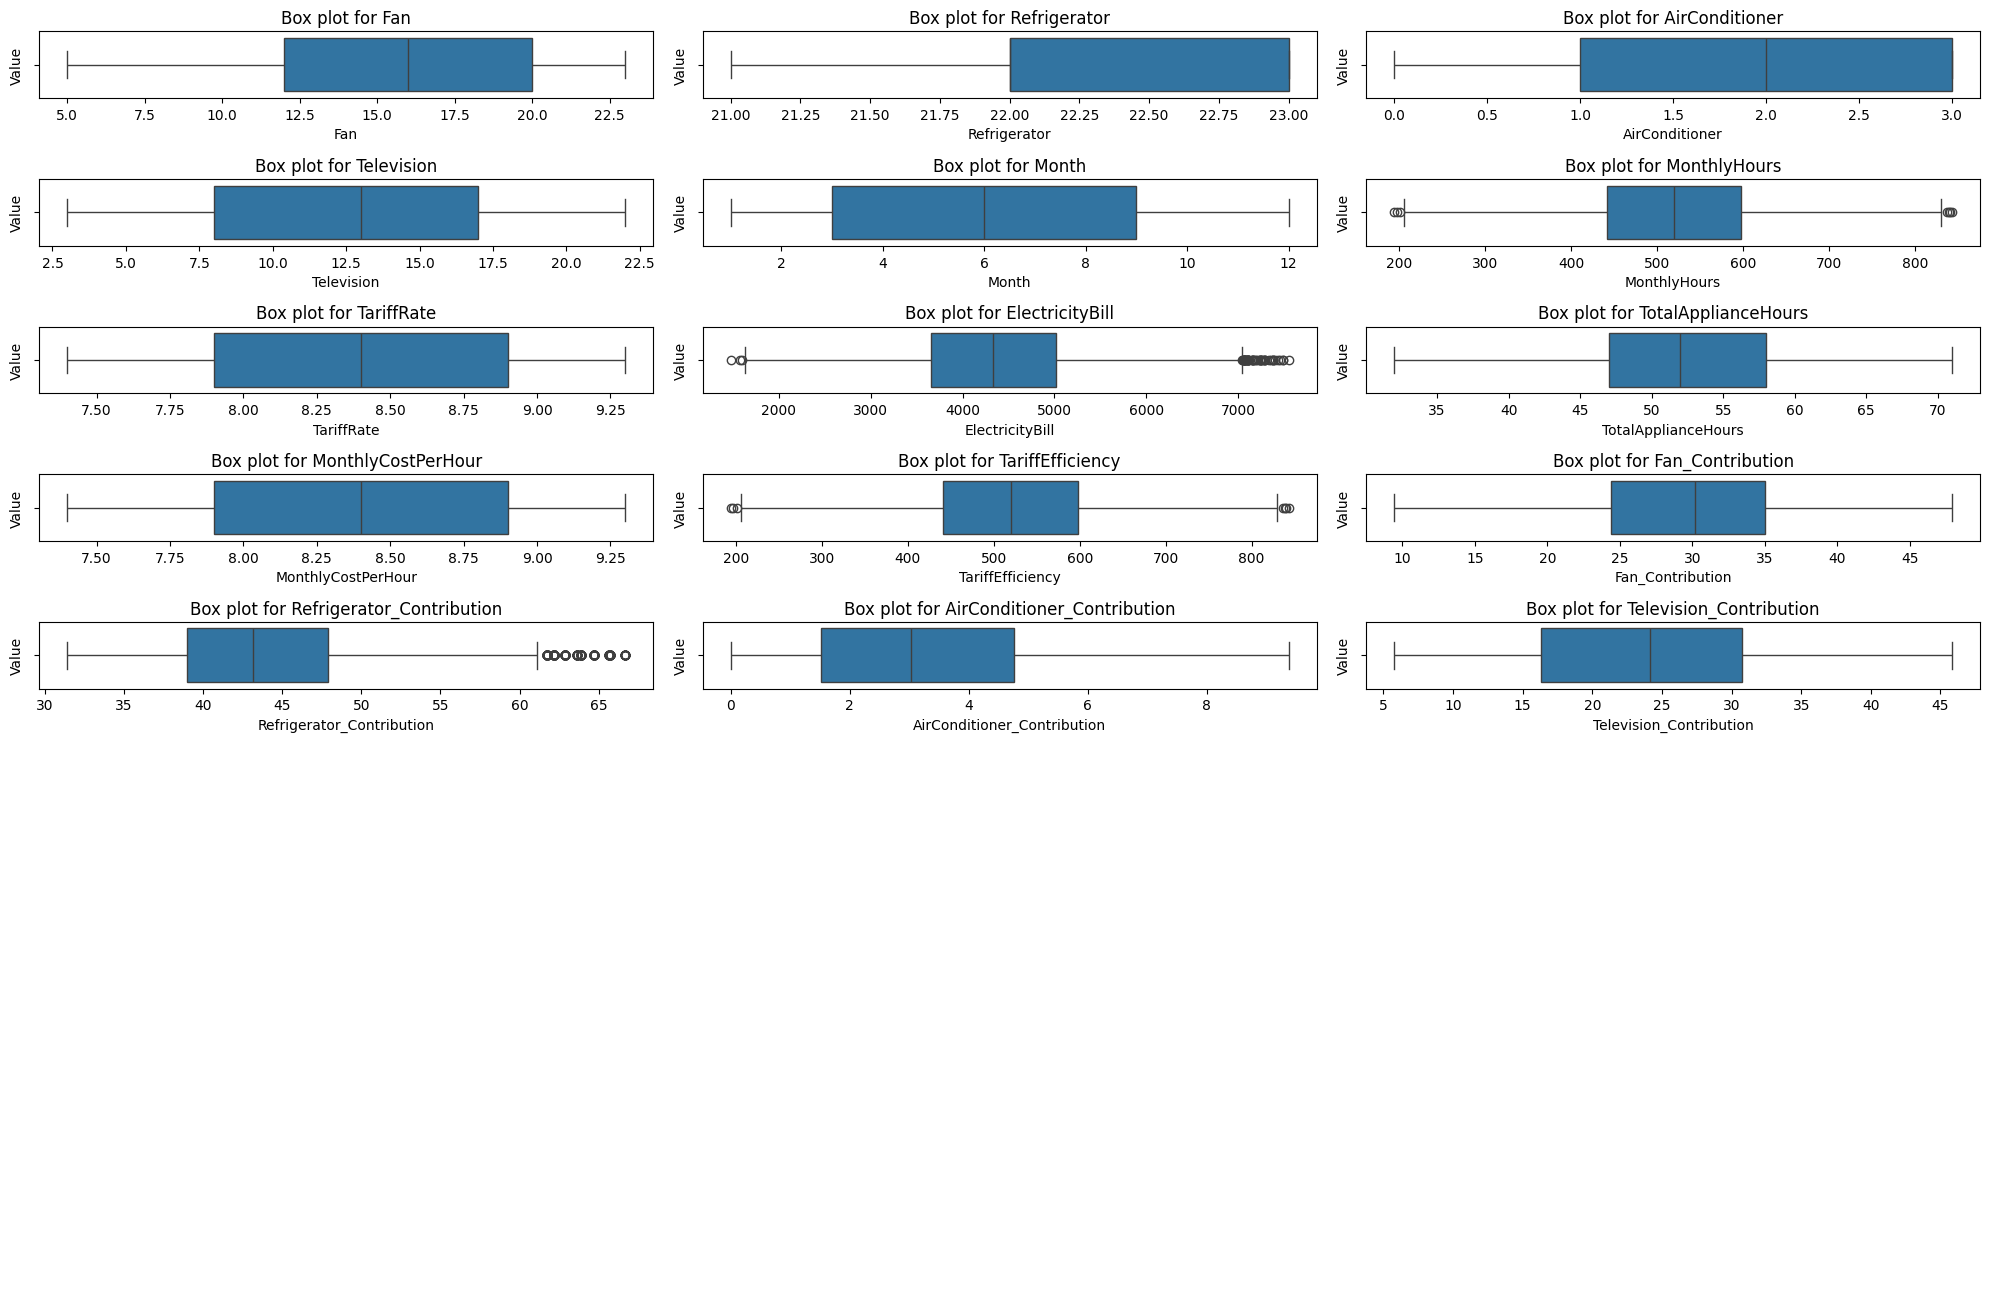

In [16]:
# Checking for outliers
#Only select numeric columns 
numeric_columns = df.select_dtypes(include=['float','integer']).columns[:]

# Grid layout
rows, cols = 9, 3
fig, axes = plt.subplots(rows, cols, figsize=(20, 13))


# Flatten 
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df[column], ax = axes[i])
    axes[i].set_title(f"Box plot for {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Value')
    
# Hide empty subplots 
for j in range(i + 1, rows * cols):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()


In [17]:
# Dropping outliers
# Create a copy of the data
data_copy = df.copy()
# Select only numeric columns
numeric_data = data_copy.select_dtypes(include=['float','integer'])

# Calculate q1, q3, and IQR for numeric data only
q1 = numeric_data.quantile(0.20)  # .20
q3 = numeric_data.quantile(0.80)  # .80
IQR = q3 - q1

# Lower and upper bounds for identifying outliers
lower_bound = q1 - (1.5 * IQR)
upper_bound = q3 + (1.5 * IQR)

# Identify outliers in numeric columns
outliers_ = set()
for col in numeric_data.columns:
    outliers = numeric_data[(numeric_data[col] < lower_bound[col]) | (numeric_data[col] > upper_bound[col])]
    outliers_.update(outliers.index)

# Count number of rows before removing outliers
num_rows_before = len(data_copy)

# Remove rows with outliers from the original DataFrame (important!)
data_copy = data_copy.drop(index=outliers_)

# Num of rows after removing outliers
num_rows_after = len(data_copy)

# Number of rows removed
rows_removed = num_rows_before - num_rows_after

# Print the results
print(f"Number of rows before removing outliers: {num_rows_before}")
print(f"Number of rows after removing outliers: {num_rows_after}")
print(f"Number of rows removed: {rows_removed}")

df = data_copy.copy()


Number of rows before removing outliers: 29619
Number of rows after removing outliers: 29619
Number of rows removed: 0


In [19]:

# --------- Objective 1: Appliance-Specific Energy Consumption ---------

# Calculate total consumption for each appliance
appliances = ['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump']
appliance_consumption = df[appliances].mean().reset_index()
appliance_consumption.columns = ['Appliance', 'Average Consumption (kWh)']

# Sort appliances by average consumption
appliance_consumption = appliance_consumption.sort_values('Average Consumption (kWh)', ascending=False)
print("\nAverage Consumption per Appliance (kWh):")
print(appliance_consumption)

# Plot appliance-specific consumption
plt.figure(figsize=(10, 6))
sns.barplot(data=appliance_consumption, x='Average Consumption (kWh)', y='Appliance', palette='coolwarm')
plt.title('Average Energy Consumption by Appliance')
plt.xlabel('Average Consumption (kWh)')
plt.ylabel('Appliance')
plt.show()



KeyError: "['Monitor', 'MotorPump'] not in index"


Monthly Electricity Usage Trends:
    Month  ElectricityBill        Fan  Refrigerator  AirConditioner
0       1      4442.989188  15.532028     22.430845        1.506732
1       2      3947.406250  15.395833     22.406454        1.515523
2       3      4465.521161  15.505569     22.411695        1.529037
3       4      4277.322535  15.469618     22.430584        1.504628
4       5      4415.124742  15.492772     22.386617        1.472945
5       6      4256.755688  15.391806     22.414877        1.521082
6       7      4473.728002  15.571836     22.425722        1.506716
7       8      4445.277544  15.335851     22.434817        1.539746
8       9      4285.739069  15.336723     22.427063        1.537740
9      10      4447.644017  15.514903     22.407343        1.527430
10     11      4286.407523  15.438976     22.403361        1.523009
11     12      4446.882596  15.538493     22.411138        1.515152


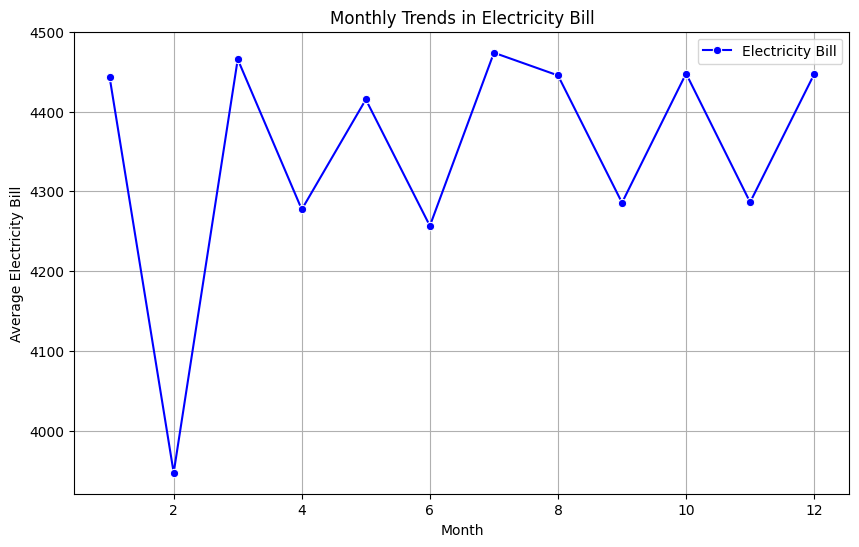

In [20]:
# --------- Objective 2: Monthly Electricity Usage Trends ---------

# Calculate average consumption and electricity bill by month
monthly_trends = df.groupby('Month')[['ElectricityBill', 'Fan', 'Refrigerator', 'AirConditioner']].mean().reset_index()
print("\nMonthly Electricity Usage Trends:")
print(monthly_trends)

# Plot total electricity bill over months
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_trends, x='Month', y='ElectricityBill', marker='o', color='blue', label='Electricity Bill')
plt.title('Monthly Trends in Electricity Bill')
plt.xlabel('Month')
plt.ylabel('Average Electricity Bill')
plt.grid()
plt.legend()
plt.show()


City-Wise Electricity Usage and Billing:
           City  ElectricityBill        Fan  Refrigerator  AirConditioner
7        Mumbai      4828.401737  15.619435     22.430510        1.533116
9   Navi Mumbai      4821.489432  15.417419     22.402549        1.496017
12         Pune      4735.372207  15.705722     22.398910        1.493733
8        Nagpur      4651.375149  15.518679     22.420682        1.571197
1       Chennai      4578.914224  15.438111     22.419653        1.514115
6       Kolkata      4538.379497  15.334609     22.427556        1.506288
10    New Delhi      4426.263395  15.459416     22.409549        1.545889
5     Hyderabad      4348.321127  15.208138     22.447053        1.533646
4       Gurgaon      4314.151205  15.528826     22.410377        1.531971
11        Noida      4229.255900  15.467645     22.427406        1.475258
3     Faridabad      4208.893564  15.542553     22.419149        1.526596
0     Ahmedabad      4071.632235  15.443163     22.403075        1.454

C:\Users\KIIT\AppData\Local\Temp\ipykernel_38832\1657182755.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_analysis, x='City', y='ElectricityBill', palette='viridis')


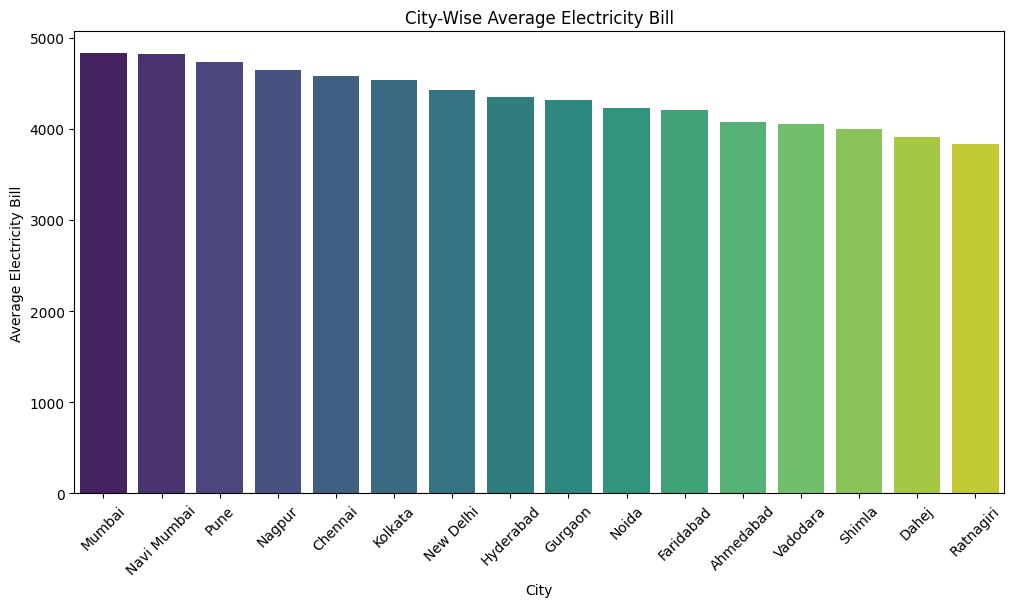

In [21]:
# --------- Objective 3: City-Wise Electricity Usage ---------

# Calculate average electricity consumption and bill by city
city_analysis = df.groupby('City')[['ElectricityBill', 'Fan', 'Refrigerator', 'AirConditioner']].mean().reset_index()
city_analysis = city_analysis.sort_values('ElectricityBill', ascending=False)
print("\nCity-Wise Electricity Usage and Billing:")
print(city_analysis)

# Plot city-wise electricity bills
plt.figure(figsize=(12, 6))
sns.barplot(data=city_analysis, x='City', y='ElectricityBill', palette='viridis')
plt.title('City-Wise Average Electricity Bill')
plt.xlabel('City')
plt.ylabel('Average Electricity Bill')
plt.xticks(rotation=45)
plt.show()


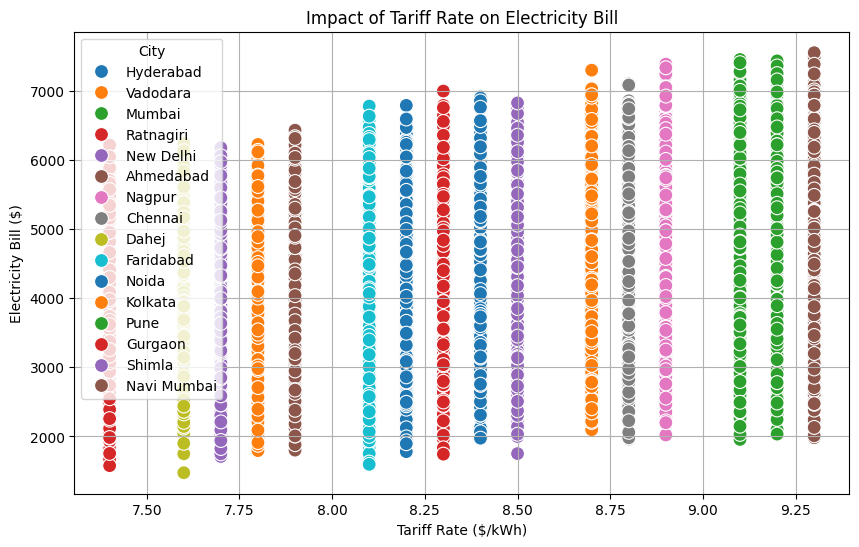


Correlation between Tariff Rate and Electricity Bill: 0.32


In [22]:
# --------- Objective 4: Impact of Tariff Rates ---------

# Analyze the relationship between TariffRate and ElectricityBill
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TariffRate', y='ElectricityBill', hue='City', palette='tab10', s=100)
plt.title('Impact of Tariff Rate on Electricity Bill')
plt.xlabel('Tariff Rate ($/kWh)')
plt.ylabel('Electricity Bill ($)')
plt.grid()
plt.show()

# Correlation between TariffRate and ElectricityBill
correlation = df[['TariffRate', 'ElectricityBill']].corr().iloc[0, 1]
print(f"\nCorrelation between Tariff Rate and Electricity Bill: {correlation:.2f}")


cities like ratnagiri, shimla, dahej and vadodara have lower tariff rate hence low electricity bill. 
It advisable for companies that have high power consumption to consider the ratnagiri, shimla, dahej and vadodara as their manufacturing site due to the lower tariff rate.
It also recommended for with low wages to consider those cities.
For cities like Navi Mumbai, Mumbai and Pune should consider other sources of electricity like solar, geothermal and wind turbines inorder to substitute so as to lower their electricity bills despite the higher tariff rates.

In [23]:
df.columns

Index(['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Month', 'City',
       'Company', 'MonthlyHours', 'TariffRate', 'ElectricityBill', 'season',
       'TotalApplianceHours', 'UsageCategory', 'MonthlyCostPerHour',
       'TariffEfficiency', 'Fan_Contribution', 'Refrigerator_Contribution',
       'AirConditioner_Contribution', 'Television_Contribution'],
      dtype='object')

In [24]:
# --------- Objective 5: Total Energy Efficiency ---------

# Calculate the proportion of total electricity consumption by each appliance
df['TotalConsumption'] = df[appliances].sum(axis=1)
appliance_efficiency = df[appliances].sum().reset_index()
appliance_efficiency.columns = ['Appliance', 'Total Consumption (kWh)']
appliance_efficiency['Proportion (%)'] = (appliance_efficiency['Total Consumption (kWh)'] / appliance_efficiency['Total Consumption (kWh)'].sum()) * 100

# Sort by proportion of consumption
appliance_efficiency = appliance_efficiency.sort_values('Proportion (%)', ascending=False)
print("\nProportion of Total Electricity Consumption by Appliance:")
print(appliance_efficiency)

# Plot energy efficiency by appliance
plt.figure(figsize=(10, 6))
sns.barplot(data=appliance_efficiency, x='Proportion (%)', y='Appliance', palette='crest')
plt.title('Proportion of Total Electricity Consumption by Appliance')
plt.xlabel('Proportion of Total Consumption (%)')
plt.ylabel('Appliance')
plt.show()

KeyError: "['Monitor', 'MotorPump'] not in index"

The refrigerator has highest electricity consumption rate followed by the fan and television.
Companies that want to venture into electric equipments like refrigerator, fan and television should make energy saving equipments that give them a competitive edge over current market.

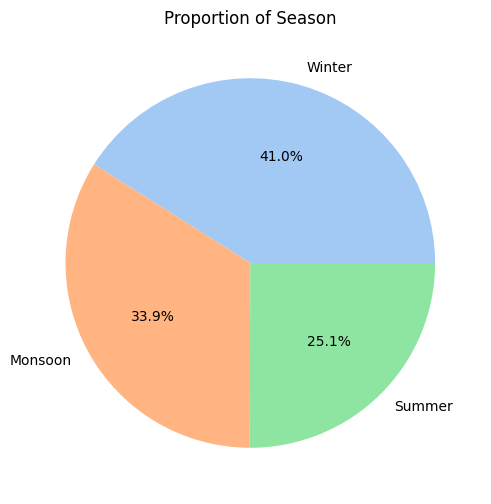

In [25]:
# seasonal pie chart distribution
    # Pie chart
plt.figure(figsize=(6, 6))
df['season'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Season')
plt.ylabel('')
plt.show()

It is noted that during winter there is higher elecricity consumption compared to other seasons.


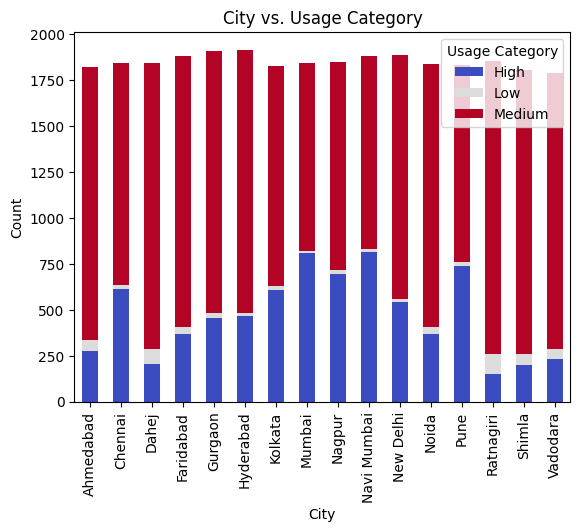

In [26]:
# Stacked bar chart example
pd.crosstab(df['City'], df['UsageCategory']).plot(kind='bar', stacked=True, cmap='coolwarm')
plt.title('City vs. Usage Category')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Usage Category')
plt.show()


In [27]:
# --------- Step 1: Seasonal Analysis ---------

# Group by season and calculate average electricity bill, tariff efficiency, and appliance contributions
seasonal_analysis = df.groupby('season')[
    ['ElectricityBill', 'TariffEfficiency', 'MonthlyCostPerHour'] + 
    ['Fan_Contribution', 'Refrigerator_Contribution', 'AirConditioner_Contribution', 
     'Television_Contribution', 'Monitor_Contribution', 'MotorPump_Contribution']
].mean().reset_index()

print("\nSeasonal Analysis Results:")
print(seasonal_analysis)

# Plot seasonal electricity bills
plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_analysis, x='season', y='ElectricityBill', palette='coolwarm')
plt.title('Average Electricity Bill by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Electricity Bill ($)', fontsize=12)
plt.grid(True)
plt.show()



KeyError: "Columns not found: 'MotorPump_Contribution', 'Monitor_Contribution'"

In [28]:
# Plot seasonal appliance contributions
appliance_contributions = seasonal_analysis.melt(
    id_vars='season', 
    value_vars=['Fan_Contribution', 'Refrigerator_Contribution', 'AirConditioner_Contribution', 
                'Television_Contribution', 'Monitor_Contribution', 'MotorPump_Contribution'],
    var_name='Appliance',
    value_name='Contribution (%)'
)

plt.figure(figsize=(12, 8))
sns.barplot(data=appliance_contributions, x='season', y='Contribution (%)', hue='Appliance', palette='Set2')
plt.title('Appliance Contribution to Energy Consumption by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.legend(title='Appliance', fontsize=10, loc='upper right')
plt.grid(True)
plt.show()


NameError: name 'seasonal_analysis' is not defined

In [ ]:
# --------- Step 2: Cost Efficiency by Season and City ---------

# Group by city and season to calculate cost efficiency
city_season_analysis = df.groupby(['City', 'season'])[['MonthlyCostPerHour', 'TariffEfficiency']].mean().reset_index()
print("\nCost Efficiency by City and Season:")
print(city_season_analysis)

# Plot cost efficiency by season for top cities
plt.figure(figsize=(14, 8))
sns.barplot(data=city_season_analysis, x='season', y='MonthlyCostPerHour', hue='City', palette='viridis')
plt.title('Monthly Cost Per Hour by City and Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Monthly Cost Per Hour ($)', fontsize=12)
plt.legend(title='City', fontsize=10, loc='upper right')
plt.grid(True)
plt.show()


In [ ]:
# --------- Step 3: UsageCategory Trends ---------

# Count the number of occurrences of each usage category by season
usage_category_analysis = df.groupby(['season', 'UsageCategory']).size().reset_index(name='Count')

# Plot usage categories by season
plt.figure(figsize=(10, 6))
sns.barplot(data=usage_category_analysis, x='season', y='Count', hue='UsageCategory', palette='pastel')
plt.title('Usage Categories by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Count')
plt.legend(title='Usage Category', fontsize=10, loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
# --------- Step 4: Appliance Usage Patterns ---------

# Calculate average TotalApplianceHours and TotalConsumption by season
season_usage_analysis = df.groupby('season')[['TotalApplianceHours', 'TotalConsumption']].mean().reset_index()
print("\nSeasonal Appliance Usage and Total Consumption:")
print(season_usage_analysis)

# Plot TotalApplianceHours and TotalConsumption by season
plt.figure(figsize=(10, 6))
sns.lineplot(data=season_usage_analysis, x='season', y='TotalApplianceHours', marker='o', label='Total Appliance Hours', color='blue')
sns.lineplot(data=season_usage_analysis, x='season', y='TotalConsumption', marker='o', label='Total Consumption (kWh)', color='red')
plt.title('Total Appliance Usage and Consumption by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Value')
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


In [ ]:
df = df.drop(columns=['Fan_Contribution', 'Refrigerator_Contribution', 'AirConditioner_Contribution', 
                     'Television_Contribution', 'Monitor_Contribution', 'MotorPump_Contribution', 
                      'MonthlyCostPerHour', 'MotorPump', 'TotalConsumption', 'Monitor', 'TariffEfficiency'])


In [ ]:
df_new = df.copy()

df_new.to_csv(r'C:/Users/KIIT/Desktop/MLOPs/electricitybills/dataset/electricity_bill_dataset.csv', index=False)

In [ ]:
df_new.columns

In [ ]:
df_new.info()

In [ ]:
df_new.describe()

In [ ]:
cat_cols = df_new.select_dtypes(include=['object','category']).columns
num_cols = df_new.select_dtypes(include=['number']).columns
print(cat_cols)
print("\n")
print(num_cols)

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"Unique values in '{col}' column: {unique_values}")

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Unique values in '{col}' column: {unique_values}")

In [ ]:
df_new['season'].unique()

Gradient Boosting Model

one hot encoder

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create a list of columns to encode
categorical_columns = ['City', 'Company', 'season', 'UsageCategory']

# Create a copy of the DataFrame with the selected columns
encoded_df = df.copy()

# Create an instance of OneHotEncoder
# sparse=False to produce a dense array and drop='first' to drop the first category of each variable
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Iterate through each categorical column

for column in categorical_columns:
    # Fit and transform the selected column
    one_hot_encoded = encoder.fit_transform(encoded_df[[column]])

    # Create a DataFrame with one-hot encoded columns
    one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out([column]))

    # Concatenate the one-hot encoded DataFrame with the original DataFrame
    encoded_df = pd.concat([encoded_df, one_hot_df], axis=1)

    # Drop the original categorical column
    encoded_df = encoded_df.drop([column], axis=1)

# Display the resulting DataFrame
df= encoded_df.copy()

df.head()

In [ ]:
df.describe()

In [ ]:
df_new.columns

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Drop null values
df = df.dropna()

# Features and target variable
X = df.drop(columns=['ElectricityBill'])
y = df['ElectricityBill']

# Train-validation-test split (Train: 64%, Val: 16%, Test: 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.36, random_state=127)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.55, random_state=127)  # 16% Val, 20% Test


In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# time 
import time

# Define the models
models = {
    #'Decision Tree': DecisionTreeRegressor(),
    #'Extra Trees': ExtraTreesRegressor(),
    #'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    #'KNN Regression': KNeighborsRegressor(),
    #'LGBM Regressor': LGBMRegressor(verbose=0),
    #'CatBoost Regressor': CatBoostRegressor(verbose=0),
    #'XGB Regressor': XGBRegressor()
}

# Initialize a dictionary to store results
results = {
    'Model': [], 'MAE': [], 'MSE': [], 'RMSE': [], 'MAPE': [], 'R2': [],
    'Training Time (s)': [], 'Prediction Time (s)': []
}

# Create a loop to iterate over the models
for model_name, model in models.items():
    # Measure the training time
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    # Measure the prediction time
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    prediction_time = time.time() - start_time

    # Evaluating the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    # Store results in a dictionary
    results['Model'].append(model_name)
    results['MAE'].append(mae)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)
    results['MAPE'].append(mape)
    results['Training Time (s)'].append(training_time)
    results['Prediction Time (s)'].append(prediction_time)

# Create a DataFrame for results in dictionary
results_df = pd.DataFrame(results)

# Display the results
results_df.head(8)

In [ ]:
pip install --upgrade nbformat ipykernel jupyter

In [ ]:
conda install -c conda-forge nbformat ipython notebook jupyterlab -y

In [ ]:
conda activate elec_bill

In [ ]:
conda install -c conda-forge ipykernel nbformat ipython -y

In [ ]:
pip install ipykernel install --user --name elec_bill

In [ ]:
# Plotting a grouped bar graph
import plotly.express as px
fig = px.bar(results_df, x='Model',
             y=['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Training Time (s)', 'Prediction Time (s)'],
             labels={'value': 'Metric Value'}, 
             title='Best Model',
             barmode = 'group')

# Update layout to vary length and width
fig.update_layout(
    width=1000,  # Set the width of the entire plot
    height=700,  # Set the height of the entire plot
    bargap=0.2,  # Set the gap between bars
)
             
# fig.show()

In [ ]:
# Scater plot

# Define the grid layout
rows, cols = 3, 3

# Specify the figure size for the entire grid
plt.figure(figsize=(15, 12))

# Loop over models
for idx, (model_name, model) in enumerate(models.items(), 1):
    # Fit the model to training data
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data
    y_pred = model.predict(X_test_scaled)

    # Scatter plot of Predictions vs. Actual Values for each model
    plt.subplot(rows, cols, idx)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  # Diagonal line for perfect predictions
    plt.title(f'{model_name} Predictions vs. Actual Values')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Define the grid layout
rows, cols = 3, 3
plt.figure(figsize=(15, 12))

# Loop over models
for idx, (model_name, model) in enumerate(models.items(), 1):
    # Fit the model to training data
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data
    y_pred = model.predict(X_test_scaled)

    # Calculate residuals
    residuals = y_test - y_pred

    # Residual plot for each model
    plt.subplot(rows, cols, idx)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name} Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Kernel Density Plot
# Define the grid layout
rows, cols = 3, 3
plt.figure(figsize=(15, 12))

# Loop over models
for idx, (model_name, model) in enumerate(models.items(), 1):
    # Fit the model to training data
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data
    y_pred = model.predict(X_test_scaled)

    # Calculate residuals
    residuals = y_test - y_pred

    # Kernel density plot for residuals of each model
    plt.subplot(rows, cols, idx)
    sns.kdeplot(residuals, fill=True)
    plt.title(f'{model_name} Kernel Density Plot')
    plt.xlabel('Residuals')
    plt.ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats


stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [ ]:
# Initialize the Gradient Boosting Regressor
rf_model = GradientBoostingRegressor()

# Initialize a dictionary to store results
results = {
    'Model': [], 'MAE': [], 'MSE': [], 'RMSE': [], 'MAPE': [], 'R2': [],
    'Adjusted R2': [], 'COD': [], 'Training Time (s)': [], 'Prediction Time (s)': []
}

# Measure the training time
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

# Measure the prediction time
start_time = time.time()
y_pred = rf_model.predict(X_test_scaled)
prediction_time = time.time() - start_time

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

# Calculate Coefficient of Determination (COD) (it's equivalent to R2 in sklearn)
cod = r2  # COD is the same as R2 in sklearn metrics.

# Calculate Adjusted R2
n = X_test_scaled.shape[0]  # Number of samples
p = X_test_scaled.shape[1]  # Number of features
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Store results in a dictionary
results['Model'].append('Gradient Boosting Model')
results['MAE'].append(mae)
results['MSE'].append(mse)
results['RMSE'].append(rmse)
results['R2'].append(r2)
results['Adjusted R2'].append(adjusted_r2)
results['COD'].append(cod)
results['MAPE'].append(mape)
results['Training Time (s)'].append(training_time)
results['Prediction Time (s)'].append(prediction_time)

# Create a DataFrame for results in dictionary
results_df = pd.DataFrame(results)

# Display the results
results_df

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [ ]:
plt.hist(residuals, bins=30, alpha=0.7)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Residual plot for each model
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Random Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
## KDE plot 
# Kernel density plot for residuals of each model
sns.kdeplot(residuals, fill=True)
plt.title('Random Forest Kernel Density Plot')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [ ]:
# Get Feature Importance
feature_importance =  model.feature_importances_

# Create a DataFrame to view feature importance 
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[45:75]

# Plot Horizontal Bar Graph
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Model Feature Importance')
plt.gca().invert_yaxis()  # Invert the y-axis to have most important at the top
plt.tight_layout()  # Adjust layout for better visualization
plt.show()

In [ ]:
pip install optuna

In [ ]:
conda install -c conda-forge ipywidgets

In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression




# Define Objective Function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_float('max_features', 0.6, 1.0),  # Replaces colsample_bytree
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 1.0),  # Replaces gamma
        'random_state': 42  # Fixed for reproducibility
    }
    
    # Initialize the GradientBoostingRegressor model
    gbm = GradientBoostingRegressor(**params)

    # Train the model
    gbm.fit(X_train_scaled, y_train)

    # Predict on test data
    y_pred = gbm.predict(X_test_scaled)

    # Compute MAE (Lower is better)
    mae_test = mean_absolute_error(y_test, y_pred)

    return mae_test

# Run Optuna Optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Print Best Parameters
print("Best Hyperparameters:", study.best_params)


In [ ]:
# Evaluate the model on the testing data
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)
mape_test = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

# Print evaluation metrics
print("MAE:", mae_test)
print("R2:", r2_test)
print("MAPE:", mape_test)
print("MSE:", mse_test)
print("RMSE:", rmse_test)


In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Residual plot for each model
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Random Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
## KDE plot 
# Kernel density plot for residuals of each model
sns.kdeplot(residuals, fill=True)
plt.title('Random Forest Kernel Density Plot')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

# Assume df is already loaded
# Drop null values
df = df.dropna()

# Features and target variable
X = df.drop(columns=['ElectricityBill'])
y = df['ElectricityBill']

# Train-validation-test split (Train: 64%, Val: 16%, Test: 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.36, random_state=127)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.55, random_state=127)  # 16% Val, 20% Test

# Feature Scaling (Not strictly required for trees, but can help)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Gradient Boosting Model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=127
)

# Train the model
start_time = time.time()
gb_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

# Make predictions
y_train_pred = gb_model.predict(X_train_scaled)
y_val_pred = gb_model.predict(X_val_scaled)
y_test_pred = gb_model.predict(X_test_scaled)

# Evaluate the model
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Training Time: {train_time:.2f} seconds")
print(f"Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}, Test MAE: {test_mae:.4f}")
print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")
print(f"Train R²: {train_r2:.4f}, Val R²: {val_r2:.4f}, Test R²: {test_r2:.4f}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

# Define KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=127)

# Store results
cv_results = {'Fold': [], 'MAE': [], 'MSE': [], 'RMSE': [], 'MAPE': [], 'R2': []}

# Perform cross-validation
fold = 1
for train_idx, val_idx in kf.split(X, y):
    # Split data
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    # Scale data (optional for Gradient Boosting but improves performance)
    scaler = StandardScaler()
    X_train_cv_scaled = scaler.fit_transform(X_train_cv)
    X_val_cv_scaled = scaler.transform(X_val_cv)

    # Train the model
    gb_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=127
    )
    gb_model.fit(X_train_cv_scaled, y_train_cv)

    # Predict on validation fold
    y_pred_cv = gb_model.predict(X_val_cv_scaled)

    # Compute evaluation metrics
    mae_cv = mean_absolute_error(y_val_cv, y_pred_cv)
    mse_cv = mean_squared_error(y_val_cv, y_pred_cv)
    rmse_cv = np.sqrt(mse_cv)
    mape_cv = np.mean(np.abs((y_val_cv - y_pred_cv) / y_val_cv)) * 100
    r2_cv = r2_score(y_val_cv, y_pred_cv)

    # Store fold results
    cv_results['Fold'].append(f'Fold {fold}')
    cv_results['MAE'].append(mae_cv)
    cv_results['MSE'].append(mse_cv)
    cv_results['RMSE'].append(rmse_cv)
    cv_results['MAPE'].append(mape_cv)
    cv_results['R2'].append(r2_cv)

    fold += 1

# Create DataFrame with results
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)


In [ ]:
# Predict on test set
y_pred_test = gb_model.predict(X_test_scaled)

# Evaluate model on test set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
r2_test = r2_score(y_test, y_pred_test)

# Print test set results
print(f"Test Set Results for Gradient Boosting Regressor:")
print(f"MAE: {mae_test:.4f}, MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAPE: {mape_test:.2f}%, R2: {r2_test:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Define the model
gb_model = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    random_state=127
)

# First, fit the model
gb_model.fit(X_train_scaled, y_train)

# Now, track RMSE at each iteration
train_rmse = []
val_rmse = []

for y_pred_train, y_pred_val in zip(gb_model.staged_predict(X_train_scaled), gb_model.staged_predict(X_val_scaled)):
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

# Plot Training vs Validation Loss (RMSE)
plt.figure(figsize=(8, 5))
plt.plot(train_rmse, label='Train RMSE', color='blue')
plt.plot(val_rmse, label='Validation RMSE', color='red')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Gradient Boosting Training vs Validation Loss Curve')
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Define the Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    random_state=127
)

# Fit the model
gb_model.fit(X_train_scaled, y_train)

# Track RMSE for each boosting iteration
train_rmse = []
val_rmse = []

for y_pred_train, y_pred_val in zip(gb_model.staged_predict(X_train_scaled), gb_model.staged_predict(X_val_scaled)):
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    val_rmse.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

# Plot Training vs Validation Loss (RMSE)
plt.figure(figsize=(8, 5))
plt.plot(train_rmse, label='Train RMSE', color='blue')
plt.plot(val_rmse, label='Validation RMSE', color='red')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Gradient Boosting Training vs Validation Loss Curve')
plt.legend()
plt.show()
